In [71]:
# statistical tests and plots to compare the values from 2 different time points
# load the correponding dataset by un-commenting the corresponding line

In [72]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro             # for normality testS
import statsmodels.api as sm                # for linear mixed-effects models (LMM)
import statsmodels.formula.api as smf       # for linear mixed-effects models (LMM)
from statsmodels.formula.api import mixedlm # for LMM
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
# Load shape measures, SELECTED
curRoot = 'C'  # 'C' or 'D'
# NOTE sca7, 3 and 2 relabeled use CS instead of CSSyl, only sca1 use CSSyl as before
curRegion = 'CSSyl'  # CSSyl, CS or CSpreCS 
curSCA = 1      # !!! modify !!!
#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# separating time1 and time2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_max.csv'

# combining time1 and time2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_max.csv'

# combining time1 and time2, after relabelling, for CSpreCS. If CSSyl load RELABEL_REDO instead
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'

# combining time1 and time2, after relabelling and REDO for sca1
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_BIOSCA.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'

# combining time1 and time2, after relabelling for sca7, sca3 and sca2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_BIOSCA.csv'

##########################################################################################################
# different sca
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'

combined = pd.read_csv(curPath)
combined.index = combined['subjName']

combined['CAG'] = combined['CAG'].fillna(0)              ## !! CHANGE the CAG from NaN to 0, for correlation study !! ##
#combined = combined[~((combined['CAG'] != 0) & (combined['SCA'] == 0))] ## !! remove controls that have CAG non-zeros !! ##


##  Careful!! Time point of CERMOI 3 to 2
#combined.loc[combined['Time_point'] == 3, 'Time_point'] = 2

#####  Careful!! Here getting only the BIOSCA subjects!!!  #####
#combined = combined[combined['CodeICM'] == 'BIOSCA']

# for specific analysis
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]
combined_only_ctl = combined[combined['SCA'] == 0]

combined_only_ctl_BIOSCA = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'BIOSCA')]
combined_only_ctl_CERMOI = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'CERMOI')]

combined_CAG = combined.dropna(subset=['CAG', 'Age_onset'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS', 'Age_onset'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS', 'Age_onset'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]


In [74]:
print(len(combined))

num_zeros = (combined['CAG'] == 0).sum()
print(f"Number of 0s in 'CAG': {num_zeros}")

count = combined[(combined['CAG'] == 0) & (combined['SCA'] != 0)].shape[0]
print(f"Number of rows where CAG == 0 and SCA != 0: {count}")

count = combined[(combined['CAG'] != 0) & (combined['SCA'] == curSCA)].shape[0]
print(f"Number of rows where CAG != 0 and SCA == curSCA: {count}")

count = combined[(combined['CAG'] != 0) & (combined['SCA'] != curSCA)].shape[0]
print(f"Number of rows where CAG != 0 and SCA != curSCA: {count}")

count = combined[(combined['CAG'] == 0) & (combined['SCA'] == 0)].shape[0]
print(f"Number of rows where CAG == 0 and SCA == 0: {count}")

subj_list = combined[(combined['CAG'] == 0) & (combined['SCA'] == 0)]['subjName']
#print(" ".join(subj_list.astype(str)))


166
Number of 0s in 'CAG': 82
Number of rows where CAG == 0 and SCA != 0: 0
Number of rows where CAG != 0 and SCA == curSCA: 62
Number of rows where CAG != 0 and SCA != curSCA: 22
Number of rows where CAG == 0 and SCA == 0: 82


In [75]:
# For comparison of the same subject across time points, add a column 'ori_subjName' without the time point postfix

# add a column to combined_only_sca 'ori_subjName' without the postfix
# Remove the postfix in the form of '_something'

combined.loc[:,'ori_subjName'] = combined['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_BIOSCA.loc[:, 'ori_subjName'] = combined_only_ctl_BIOSCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_CERMOI.loc[:, 'ori_subjName'] = combined_only_ctl_CERMOI['subjName'].str.replace(r'_.+$', '', regex=True)

combined_CAG_only_SCA.loc[:, 'ori_subjName'] = combined_CAG_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_CCFS_only_SCA.loc[:, 'ori_subjName'] = combined_CCFS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_INAS_only_SCA.loc[:, 'ori_subjName'] = combined_INAS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
#print(combined_only_ctl)

C:\Users\joyca\AppData\Local\Temp\ipykernel_26240\1243336850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_26240\1243336850.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_26240\1243336850.py:9:

In [76]:
# Remove subjects with only one time point

def removeSingleTimePointReIndex(df):
  valid_subjects = df['ori_subjName'].value_counts()   # ensure each subject has two time points
  df = df[df['ori_subjName'].isin(valid_subjects[valid_subjects > 1].index)]
  df = df.sort_values(by=["ori_subjName", "Time_point"]).reset_index(drop=True)    
  return df

combined = removeSingleTimePointReIndex(combined)
combined_only_SCA = removeSingleTimePointReIndex(combined_only_SCA)
combined_CAG_only_SCA = removeSingleTimePointReIndex(combined_CAG_only_SCA)
combined_CCFS_only_SCA = removeSingleTimePointReIndex(combined_CCFS_only_SCA)
combined_INAS_only_SCA = removeSingleTimePointReIndex(combined_INAS_only_SCA)

In [77]:
# Centering values

def centering_values(df):
    df.loc[:,'CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df.loc[:,'SARA_centered'] = df['SARA'] - df['SARA'].mean()
    df.loc[:,'CCFS_centered'] = df['CCFS'] - df['CCFS'].mean()
    df.loc[:,'INAS_centered'] = df['INAS'] - df['INAS'].mean()    
    df.loc[:,'Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df.loc[:,'Age_centered'] = df['Age'] - df['Age'].mean()
    df.loc[:,'iso1_centered'] = df['iso1'] - df['iso1'].mean()   
    df.loc[:,'iso2_centered'] = df['iso2'] - df['iso2'].mean()       
    df.loc[:,'iso3_centered'] = df['iso3'] - df['iso3'].mean()   
    df.loc[:,'UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
    df.loc[:,'UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
    df.loc[:,'UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
    df.loc[:,'UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
    df.loc[:,'UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
    df.loc[:,'UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
    df.loc[:,'iso1_asy_centered'] = df['iso1_asy'] - df['iso1_asy'].mean()   
    df.loc[:,'iso2_asy_centered'] = df['iso2_asy'] - df['iso2_asy'].mean()       
    df.loc[:,'iso3_asy_centered'] = df['iso3_asy'] - df['iso3_asy'].mean()      
    return df

combined_centered = centering_values(combined)
combined_only_SCA_centered =  centering_values(combined_only_SCA)
combined_CAG_only_SCA_centered =  centering_values(combined_CAG_only_SCA)
combined_CCFS_only_SCA_centered = centering_values(combined_CCFS_only_SCA)
combined_INAS_only_SCA_centered = centering_values(combined_INAS_only_SCA)

In [78]:
#################  verifications of correlations, collinearity  #################
df = combined_CAG_only_SCA

# print correlation
#print(df[['Age', 'Age_onset']].corr())
#print(df[['CAG', 'SARA']].corr())
#print(df[['CAG', 'Age_onset']].corr())

#print(df['Age_onset'].isnull().sum())
#print(df[df['Age_onset'].isnull()])

print("Number of rows in DataFrame:", len(df))
print("DataFrame shape:", df.shape)
print("Unique subject names:", df['ori_subjName'].unique())
print("Rows with NaN in groups:", df[df["ori_subjName"].isnull()])

#print("Max index:", df.index.max())
#print("Unique subjects:", df["ori_subjName"].nunique())
#print("Rows per subject:", df["ori_subjName"].value_counts())
#print("Group labels shape:", df['ori_subjName'].shape)
#print("Group sizes:")
#print(df.groupby("ori_subjName").size())
#print("Row indices for each group:")
#print(groups)

Number of rows in DataFrame: 56
DataFrame shape: (56, 79)
Unique subject names: ['L001013LF' 'L001029DJ' 'L001033BM' 'L001039CD' 'L001068RA' 'L001069DB'
 'L001076SC' 'L001077MR' 'L001083RB' 'L001084CJ' 'L001087RN' 'L001090RD'
 'L001093TL' 'L001095MP' 'flip-R001013LF' 'flip-R001029DJ'
 'flip-R001033BM' 'flip-R001039CD' 'flip-R001068RA' 'flip-R001069DB'
 'flip-R001076SC' 'flip-R001077MR' 'flip-R001083RB' 'flip-R001084CJ'
 'flip-R001087RN' 'flip-R001090RD' 'flip-R001093TL' 'flip-R001095MP']
Rows with NaN in groups: Empty DataFrame
Columns: [subjName, label, surface_talairach, surface_native, maxdepth_talairach, maxdepth_native, meandepth_talairach, meandepth_native, hull_junction_length_talairach, hull_junction_length_native, GM_thickness, opening, Randomization, SCA, CAG, Sex, Age, SARA, INAS, Time_point, CodeICM, iso1, iso2, iso3, UMAP1_U1, UMAP1_U2, UMAP1_U3, UMAP2_U3, UMAP1_U4, UMAP2_U4, Age_onset, Group_ctl_pre_pat, Handedness, CCFS, Disease_duration, allele1, allele2, side, SCA_side

In [79]:
df = combined
print(df['ori_subjName'].isna().sum())

print(df['ori_subjName'].unique()[:50])
print(df['ori_subjName'].dtype)


0
['L00001PJ' 'L00004PA' 'L00011EG' 'L00023EA' 'L00027EF' 'L00030CA'
 'L00031CP' 'L00036DC' 'L001013LF' 'L001019DA' 'L001020HG' 'L001022LM'
 'L001029DJ' 'L001032SG' 'L001033BM' 'L001037GA' 'L001039CD' 'L001040BF'
 'L001049BD' 'L001060MJ' 'L001065BC' 'L001068RA' 'L001069DB' 'L001073PM'
 'L001075HJ' 'L001076SC' 'L001077MR' 'L001079LP' 'L001083RB' 'L001084CJ'
 'L001085BN' 'L001087RN' 'L001090RD' 'L001091MR' 'L001093TL' 'L001095MP'
 'L001096BC' 'L001099GL' 'L001100PY' 'L001101JO' 'flip-R00001PJ'
 'flip-R00004PA' 'flip-R00011EG' 'flip-R00023EA' 'flip-R00027EF'
 'flip-R00030CA' 'flip-R00031CP' 'flip-R00036DC' 'flip-R001013LF'
 'flip-R001019DA']
object


In [231]:
#cag_values = combined_CAG_only_SCA[['ori_subjName','CAG']]
cag_values_sorted = combined_CAG_only_SCA[['ori_subjName', 'CAG']].sort_values(by='CAG', ascending=True)
#print(cag_values_sorted)

# Select the columns
cag_values = combined_CAG_only_SCA[['ori_subjName', 'CAG']]

# Drop duplicate CAG values (keep first occurrence) and sort by CAG
cag_sorted_unique = cag_values.drop_duplicates(subset='CAG').sort_values(by='CAG')

# Display the result
print(cag_sorted_unique)


   ori_subjName   CAG
16    L001083RB  40.0
20    L001087RN  41.0
18    L001084CJ  42.0
14    L001077MR  44.0
12    L001076SC  45.0
0     L001013LF  46.0
8     L001068RA  48.0
2     L001029DJ  50.0
4     L001033BM  54.0
10    L001069DB  57.0
6     L001039CD  62.0


In [80]:
print(combined["iso1_centered"].describe())

count    1.600000e+02
mean    -8.881784e-17
std      4.329320e+00
min     -9.467267e+00
25%     -3.047340e+00
50%     -1.534160e-01
75%      2.547431e+00
max      1.136746e+01
Name: iso1_centered, dtype: float64


In [81]:
print(combined_CAG_only_SCA['CAG'].describe())

count    56.000000
mean     46.928571
std       6.455039
min      40.000000
25%      42.000000
50%      45.000000
75%      50.000000
max      62.000000
Name: CAG, dtype: float64


In [82]:
combined_CAG_only_SCA['Sex'].value_counts()

Sex
1    36
2    20
Name: count, dtype: int64

In [225]:
len(combined_CAG_only_SCA)

56

In [84]:
############################  The LMM tests for verification of result, ADDING the controls  #############################
## To understand if there is a correlation when adding the controls, CAG set to 0
## for the presymptomatic ones, use the existing CAG values if existing

df = combined_centered

def test_LMM(df):

    measure =  'iso1_centered'  # 'UMAP1_U2_centered'
    x_var = 'CAG_centered'          # DEFAULT
    covariates = 'Age_centered + C(side)'  # DEFAULT 

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
#        re_formula="~CAG_centered"  ######### !!! adding a random slope for comparison 
    )

    result = model_lmm.fit(reml=True)   # for small samples: restricted maximum likelihood
#    result = model_lmm.fit()           # default to maximum likelihood
    return result

####################################################################################################
#df = combined_CAG_only_SCA
result = test_LMM(df)
print(result.summary())

#print(result.cov_re)
#slope_variance = result.cov_re.loc['CAG_centered', 'CAG_centered']
#print("Random slope variance:", slope_variance)


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: iso1_centered
No. Observations: 160     Method:             REML         
No. Groups:       80      Scale:              0.1540       
Min. group size:  2       Log-Likelihood:     -297.9366    
Max. group size:  2       Converged:          Yes          
Mean group size:  2.0                                      
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.823    0.668  1.231 0.218 -0.487  2.133
C(side)[T.R]     -1.646    0.945 -1.741 0.082 -3.499  0.207
CAG_centered     -0.038    0.022 -1.758 0.079 -0.081  0.004
Age_centered     -0.009    0.025 -0.372 0.710 -0.058  0.040
Group Var        17.798   10.371                           



In [211]:
############################  The LMM tests for verification of result, patient only  #############################
df = combined_CAG_only_SCA_centered
#df = combined_CAG_only_SCA       # for comparison with centered

def test_LMM(df):
    measure =  'iso1_centered'  # 'UMAP1_U2_centered'
    x_var = 'CAG_centered'                       # DEFAULT
    covariates = 'Age_onset_centered + C(side) + SARA_centered'  # DEFAULT 
    #covariates = 'Age_centered + C(side) + SARA_centered'  # test using Age
    
    
#    x_var = 'CAG_centered*Age_onset_centered'     # interaction
#    covariates = 'C(side)'                        # interaction
#    x_var = 'CAG_centered*Age_onset_centered'     # interaction adding SARA
#    covariates = 'C(side) + SARA_centered'        # interaction adding SARA    
    #covariates = 'Age_onset_centered + C(side) + C(Sex)'  # test adding Sex 

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName'],
        #re_formula="~CAG_centered"  ######### !!! adding a random slope for comparison, possible convergence issues 
    )
    result = model_lmm.fit()
    #result = model_lmm.fit(reml=True)   # for small samples: restricted maximum likelihood
    return result

####################################################################################################
result = test_LMM(df)
print(result.summary())


print(result.cov_re)

####  Quick test, only if adding a random slope in the model
#slope_variance = result.cov_re.loc['CAG_centered', 'CAG_centered']
#print("Random slope variance:", slope_variance)

#############  print estimated effect size and the standard error range  ##############
beta_cag = result.params['CAG_centered']
beta_onset = result.params['Age_onset_centered'] 
se_cag = result.bse['CAG_centered']
se_onset = result.bse['Age_onset_centered']
print(f"CAG_centered effect: {beta_cag:.3f} ± {se_cag:.3f}")
print(f"Age_onset_centered effect: {beta_onset:.3f} ± {se_onset:.3f}")

##############  print 95% confidence intervals  ##############
print()
print(" 95% confidence interval")
ci_cag = (beta_cag - 1.96 * se_cag, beta_cag + 1.96 * se_cag)
ci_onset = (beta_onset - 1.96 * se_onset, beta_onset + 1.96 * se_onset)

print(f"CAG_centered 95% CI: {ci_cag[0]:.3f} to {ci_cag[1]:.3f}")
print(f"Age_onset_centered 95% CI: {ci_onset[0]:.3f} to {ci_onset[1]:.3f}")

##############  print correlation between CAG_centered and Age_onset_centered  ##############
print(df[['CAG_centered', 'Age_onset_centered']].corr())
##############  print correlation between CAG_centered and SARA_centered  ##############
print()
print(df[['CAG_centered', 'SARA_centered']].corr())

            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: iso1_centered
No. Observations:   56      Method:             REML         
No. Groups:         28      Scale:              0.1462       
Min. group size:    2       Log-Likelihood:     -98.0409     
Max. group size:    2       Converged:          Yes          
Mean group size:    2.0                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.509    0.933  0.545 0.586 -1.320  2.339
C(side)[T.R]       -1.018    1.320 -0.771 0.441 -3.605  1.569
CAG_centered        0.818    0.288  2.838 0.005  0.253  1.383
Age_onset_centered  0.455    0.154  2.954 0.003  0.153  0.757
SARA_centered      -0.013    0.028 -0.462 0.644 -0.067  0.041
Group Var          12.125   12.688                           

           Group
Gr

In [86]:
###################################   Likelihood ratio test  ##################################
#############################  LRT as an alternative to p-values  #############################

# comparing log-likelihoods of nested models, for small sample size and the testing of a key effect
# Use reml=False for both models. REML (restricted maximum likelihood) is good for estimating variance components
# but not for comparing models with different fixed effects.
# Using a chi-square distribution with df=1 because testing 1 parameter (CAG_centered).   
#df = combined
df = combined_CAG_only_SCA_centered
#formula = "UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)"
#reduced_formula = "UMAP1_U2_centered ~ Age_onset_centered + C(side)"
formula = "iso1_centered ~ CAG_centered + Age_onset_centered + C(side)"
reduced_formula = "iso1_centered ~ Age_onset_centered + C(side)"


from scipy.stats import chi2

# Full model with SCA and Time_point
model_full = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
result_full = model_full.fit()

# Reduced model with only Time_point (i.e., removing SCA)
model_reduced = smf.mixedlm(formula = reduced_formula, data=df, groups=df["ori_subjName"])
result_reduced = model_reduced.fit()

# Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_reduced.llf)  # LRT statistic
df_diff = result_full.df_modelwc - result_reduced.df_modelwc  # difference in degrees of freedom
p_value = stats.chi2.sf(lr_stat, df_diff)  # chi-square p-value

print(f"Likelihood Ratio Test statistic: {lr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {p_value:.4g}")

Likelihood Ratio Test statistic: 6.7036
Degrees of freedom: 1
p-value: 0.009622


C:\Users\joyca\AppData\Local\Temp\ipykernel_26240\1780100204.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[curCorVal] = -df[curCorVal]


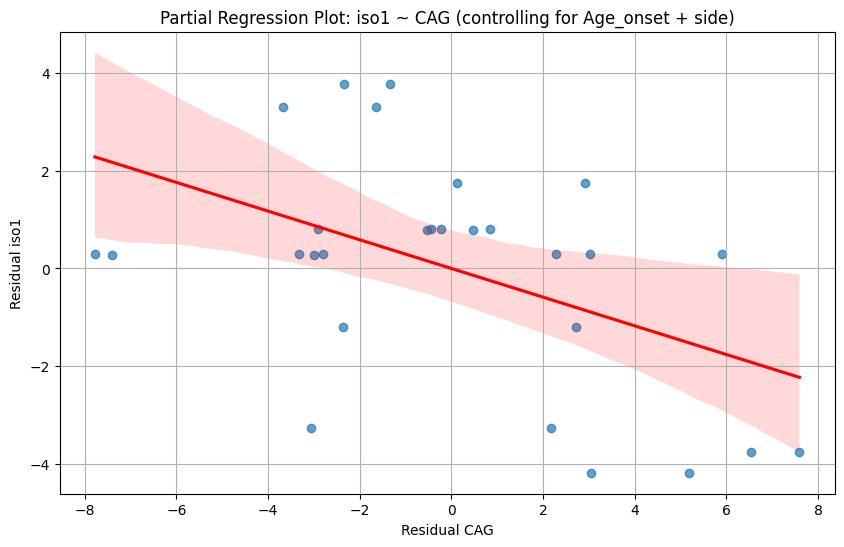

In [87]:
##############################  Plot with partial correlation  ##############################
#########################   Plotting taking into account the residuals   ##########################
# Use linear regression with Pearson's coef between residuals

combined_CAG_only_SCA_t1 = combined_CAG_only_SCA[combined_CAG_only_SCA['Time_point'] == 1]

curMeasure = 'iso1'
curCorVal = 'CAG'
#partialCorCol = ['Age', 'Sex','side']            
#partialCorParam =  'Age + Sex + side'  
partialCorCol = ['Age_onset','side']            # if SCA1, SCA3
partialCorParam =  'Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Age_onset','side']            # if SCA1, SCA3
#partialCorParam =  'Age + Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side']            # if SCA1, SCA3
#partialCorParam =  'Age + Sex + Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side','Disease_duration']            # if SCA1, SCA3
#partialCorParam =  'Age + Sex + Age_onset + side + Disease_duration'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side','CodeICM']  # if SCA2, SCA7
#partialCorParam =  'Age + Sex + Age_onset + side + CodeICM'    # if SCA2, SCA7

# Define mapping of curCorVal to DataFrame
data_map = {
    'INAS': combined_INAS_only_SCA,
    #'CAG': combined_CAG_only_SCA,     #!!!!!!!!!!!!!!!!!!! if plot all time points !!!!!!!!!!!!!!!!!!!!!
    'CAG': combined_CAG_only_SCA_t1,   #!!!!!!!!!!!!!!!!!!!   if plot time 1 only  !!!!!!!!!!!!!!!!!!!!!!
    'CCFS': combined_CCFS_only_SCA,
    'SARA': combined_only_SCA
}
curData = data_map.get(curCorVal, None)
# Optional: Raise an error or provide a message if curCorVal is invalid
if curData is None:
    print(f"Warning: No data found for curCorVal = '{curCorVal}'")
    
# Prepare the data
df = curData[[curMeasure, curCorVal] + partialCorCol] # Ensure required columns are present

################  negate the slope, optional  ################
# for matching visual direction with another figure if needed
df[curCorVal] = -df[curCorVal]
##############################################################

# Fit the OLS model using smf.ols with missing='drop'
model = smf.ols(formula=curMeasure+' ~ '+ curCorVal +' + ' + partialCorParam, data=df, missing='drop').fit()

# Partial regression: calculate residuals
residual_x = smf.ols(formula=curMeasure+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
# Residual of curCorVal regressed
residual_y = smf.ols(formula=curCorVal+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
raw_y = df[curCorVal]

# Align indices to ensure lengths match
residual_x, raw_y = residual_x.align(raw_y, join='inner')

## Plot the residuals
plt.figure(figsize=(10, 6))

# if plotting together with the shape spread of isomap
sns.regplot(x=residual_x, y=residual_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) # plot y raw CAG

# if emphasize effect of CAG on shape
#sns.regplot(x=residual_y, y=residual_x, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 

plt.ylabel('Residual '+curMeasure)      # plot x_CAG, y_shape
plt.xlabel('Residual '+curCorVal) 

# if emphasize effect of shape on CAG
#sns.regplot(x=residual_x, y=residual_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 
#plt.ylabel('Residual '+curCorVal)      # plot x_shape, y_CAG
#plt.xlabel('Residual '+curMeasure) 

plt.title('Partial Regression Plot: '+curMeasure+' ~ '+curCorVal+' (controlling for '+partialCorParam+')')
plt.grid()


#############################################################################################
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7\cor_SCA7_ctl_minU12_CAG_time1_2_ageOnsetSide_neg_Time1.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\cor_SCA1_ctl_maxIso1_CAG_time1_2_ageOnsetSide_Time1.png')

plt.show()

In [88]:
# Example: Partial regression plot: the effect of X on Y, controlling for Z1 and Z2.
#from statsmodels.graphics.regressionplots import plot_partregress
#plot_partregress('Y', 'X', ['Z1', 'Z2'], data=df)


In [89]:
###################  Calculating the ICC: intraclass correlation coefficients  ####################
#################   Testing ICC to decide to include the random intercept or not  #################

# To understand what is the proportion of variability in random intercept
# Random intercept variance (subject) / (Random intercept variance (subject) + Residual variance (error))

## NOTE:  Based on the result of the LMM test in the cell above 

# Extract random intercept variance (subject-level variance)
subject_var = result.cov_re.iloc[0, 0]

# Extract residual (within-subject / error) variance
residual_var = result.scale

print(f"Random intercept variance (subject): {subject_var:.2f}")
print(f"Residual variance (error): {residual_var:.2f}")

icc = subject_var / (subject_var + residual_var)
print(f"Intraclass Correlation Coefficient (ICC): {icc:.3f}")


Random intercept variance (subject): 12.21
Residual variance (error): 0.14
Intraclass Correlation Coefficient (ICC): 0.989


In [90]:
###################################   Likelihood ratio test  ##################################
#################   Testing LRT to decide to include the random slope or not  #################
df = combined_CAG_only_SCA_centered

# Define the formula explicitly
#formula = "UMAP1_U2_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)"
formula = "UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)"

# Model 1: Random intercept only
model_reduced = smf.mixedlm(
    formula=formula,
    data=df,
    groups=df["ori_subjName"]
)
result_reduced = model_reduced.fit()

# Model 2: Random intercept + random slope for CAG_centered
model_full = smf.mixedlm(
    formula=formula,
    data=df,
    groups=df["ori_subjName"],
    re_formula="~CAG_centered"
)
result_full = model_full.fit()

# Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_reduced.llf)  # LRT statistic
df_diff = result_full.df_modelwc - result_reduced.df_modelwc  # difference in degrees of freedom
p_value = stats.chi2.sf(lr_stat, df_diff)  # chi-square p-value

print(f"Likelihood Ratio Test statistic: {lr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {p_value:.4g}")

C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


Likelihood Ratio Test statistic: 0.0006
Degrees of freedom: 2
p-value: 0.9997


C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.001740
  warnings.warn(msg, ConvergenceWarning)
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


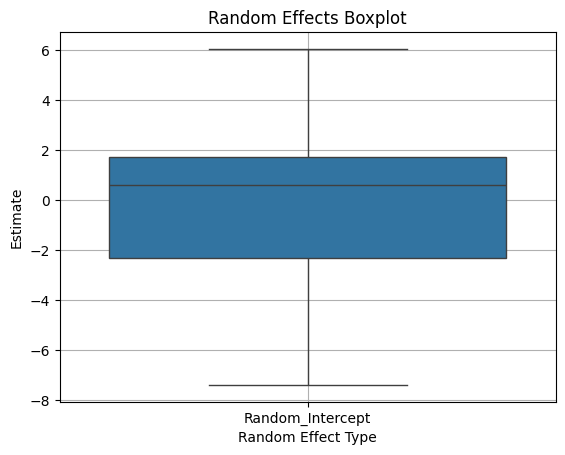

In [91]:
###################  Study random effest by group: Random Effects Boxplot  ####################

re_df = pd.DataFrame(result.random_effects).T  # transpose to get subjects as rows
re_df.columns = ['Random_Intercept'] if re_df.shape[1] == 1 else ['Random_Intercept', 'Random_Slope']
re_df = re_df.reset_index().melt(id_vars='index', var_name='Effect', value_name='Estimate')

sns.boxplot(data=re_df, x='Effect', y='Estimate')
plt.title("Random Effects Boxplot")
plt.xlabel("Random Effect Type")
plt.ylabel("Estimate")
plt.grid(True)
plt.show()


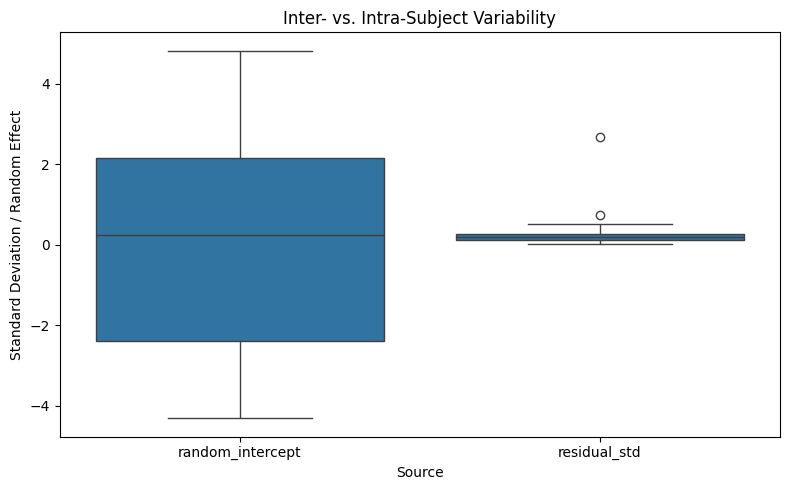

In [92]:
#########################  Plot inter vs intra subject variability  #########################

df = combined_CAG_only_SCA_centered
formula = "UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)"
model = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
result = model.fit()

# Extract random effects (inter-subject variability)
random_effects = pd.DataFrame(result.random_effects).T
random_effects.columns = ['random_intercept']

# Extract residuals (intra-subject variability)
df["residuals"] = result.resid
residuals_std_by_subject = df.groupby("ori_subjName")["residuals"].std().reset_index()
residuals_std_by_subject.columns = ["ori_subjName", "residual_std"]

# Merge both
plot_df = random_effects.merge(residuals_std_by_subject, left_index=True, right_on="ori_subjName")

# Melt for seaborn boxplot
plot_df_melted = plot_df.melt(id_vars="ori_subjName", value_vars=["random_intercept", "residual_std"],
                              var_name="Source", value_name="Value")

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Source", y="Value", data=plot_df_melted)
plt.title("Inter- vs. Intra-Subject Variability")
plt.ylabel("Standard Deviation / Random Effect")
plt.tight_layout()
plt.show()


C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


              Group  CAG_centered
L001013LF -2.973572     -0.002335
L001029DJ  4.594037      0.003608
L001033BM -1.745394     -0.001371
L001039CD  0.856399      0.000673
L001068RA -0.220546     -0.000173


C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.001740
  warnings.warn(msg, ConvergenceWarning)
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


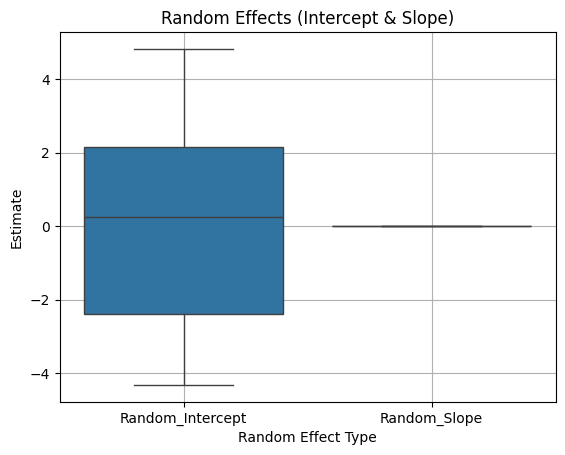

In [93]:
#################  model and plot random intercept and random slope  ###################

model_lmm = smf.mixedlm(
#    formula="iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)",
    formula="UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)",
    data=df,
    groups=df["ori_subjName"],
    re_formula="~CAG_centered"  # random intercept + slope for CAG_centered
)
result_lmm = model_lmm.fit()

##################  plot of random effect  ##################
result_lmm.random_effects

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
print(re_df.head())

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df.columns = ['Random_Intercept', 'Random_Slope']

re_df = re_df.reset_index().melt(id_vars='index', var_name='Effect', value_name='Value')
sns.boxplot(data=re_df, x='Effect', y='Value')
plt.title("Random Effects (Intercept & Slope)")
plt.xlabel("Random Effect Type")
plt.ylabel("Estimate")
plt.grid(True)
plt.show()

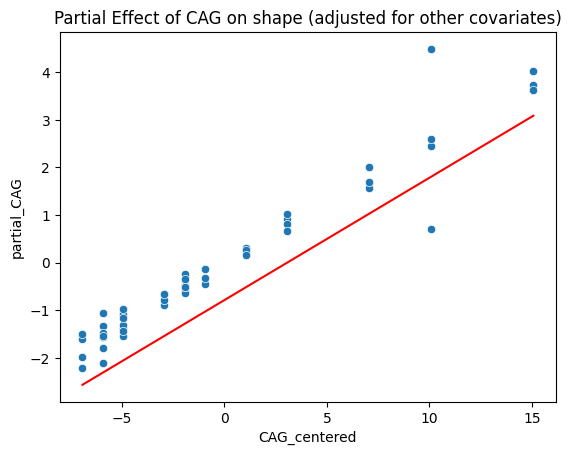

In [94]:
###################################   Verification of the model  ##################################
###  partial effect of CAG_centered  (partial residual plot)

###  Rerun the LMM model when needed!!!!!!!!  ###
df = combined_CAG_only_SCA_centered

pred_df = pd.DataFrame()
pred_df["CAG_centered"] = np.linspace(df["CAG_centered"].min(), df["CAG_centered"].max(), 100)

# Set other covariates to their mean or mode (you can change this logic)
pred_df["Age_centered"] = df["Age_centered"].mean()
pred_df["Age_onset_centered"] = df["Age_onset_centered"].mean()
pred_df["side"] = df["side"].mode()[0]  # most common side
pred_df["ori_subjName"] = df["ori_subjName"].iloc[0]  # just pick any group for prediction

# Predict from your model
pred_df["predicted"] = result.predict(pred_df)

df["fitted"] = result.fittedvalues
df["residuals"] = result.resid

# Partial residual: add back the effect of CAG only
df["partial_CAG"] = df["residuals"] + result.params["CAG_centered"] * df["CAG_centered"]

sns.scatterplot(data=df, x="CAG_centered", y="partial_CAG")
sns.lineplot(x=pred_df["CAG_centered"], y=pred_df["predicted"], color="red")
plt.title("Partial Effect of CAG on shape (adjusted for other covariates)")

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_pertialEffect_CAG.png')

plt.show()


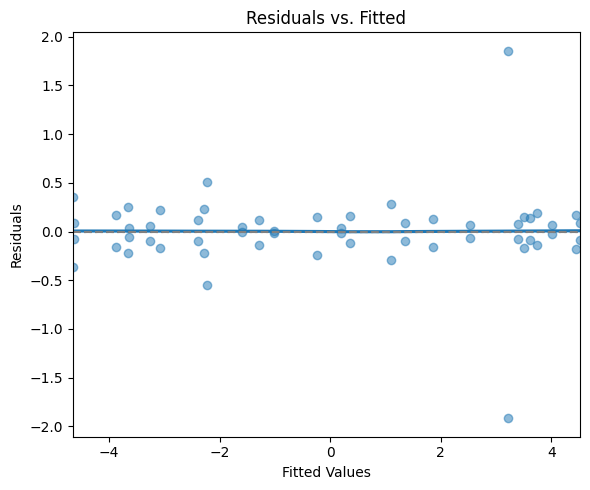

<Figure size 600x500 with 0 Axes>

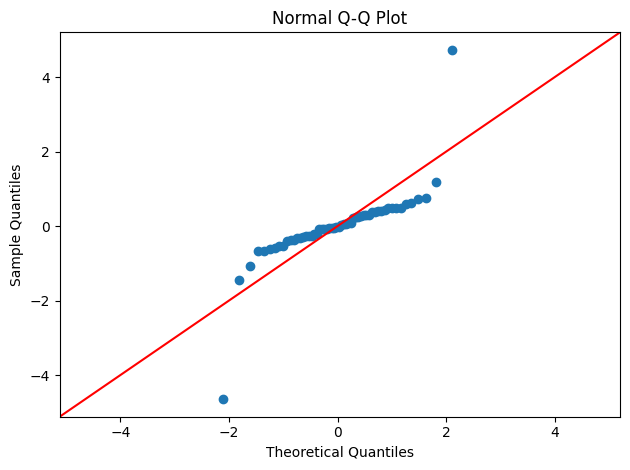

In [95]:
###################################   Verification of the model  ##################################
#################  linearity, constant variance (homoscedasticity) and normality  #################

#######################  Residual versus fitted plots  #######################
#df = combined_CAG_only_SCA
df = combined_CAG_only_SCA_centered

# Fit your LMM
formula = "UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)"
model = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
result = model.fit()

# Extract fitted values and residuals
fitted = result.fittedvalues
residuals = result.resid

# Plot 1: Residuals vs. Fitted
plt.figure(figsize=(6, 5))
sns.residplot(x=fitted, y=residuals, lowess=True, scatter_kws={'alpha': 0.5})
plt.axhline(0, color='gray', linestyle='--')  # ← fixed line
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_Residual.png')

plt.show()

########################     QQ-plots of the residual   ######################
# Plot 2: Q-Q Plot
plt.figure(figsize=(6, 5))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_QQ.png')

plt.show()


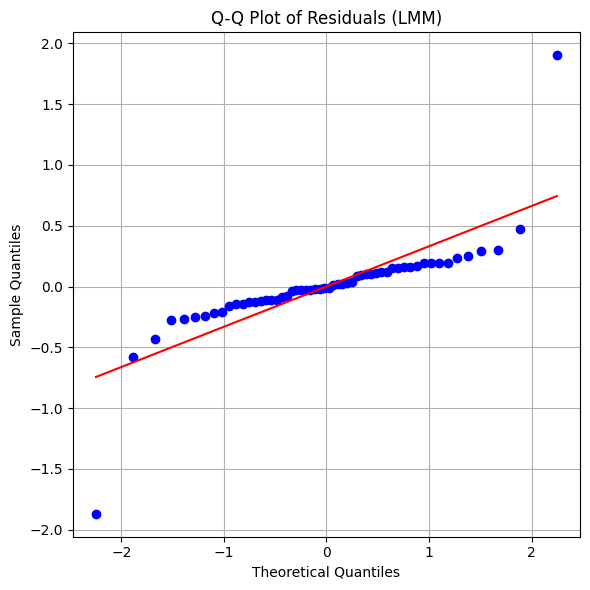

In [96]:
###########  Q-Q plot using stats.probplot instead of sm.qqplot as above  ###########
## sm.qqplot above for a quick check
## stats.probplot here for fine-grained control or integration into custom plotting pipelines

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (LMM)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

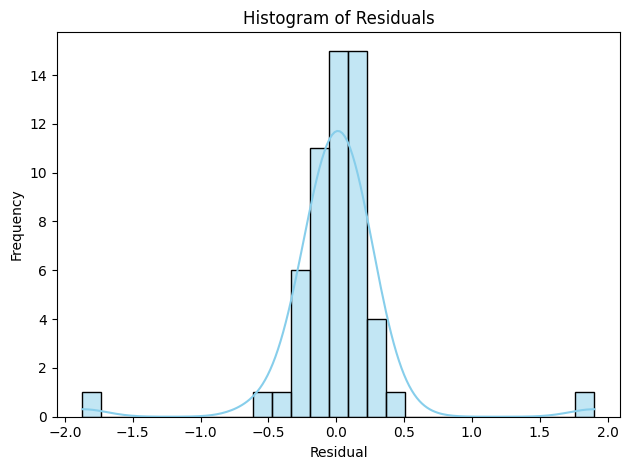

In [97]:
##################################  Plot histogram of the residuals  ###################################

residuals = result.resid
sns.histplot(residuals, kde=True, color='skyblue')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [98]:
##################  Normality test of the residual  ####################
# shapiro: if p > 0.05, not normal
from scipy.stats import shapiro
shapiro_stat, p_value = shapiro(result.resid)
print(f"Shapiro-Wilk p-value: {p_value:.4f}")

Shapiro-Wilk p-value: 0.0000


In [99]:
##################  Normality test of the residual  ####################
# Kolmogorov-Smirnov: if p > 0.05, not normal
# The K-S test is sensitive to outliers and assumes known parameters (mean and std). 
# When applied to estimated residuals, it can be conservative or misleading.
# It’s generally less powerful than the Shapiro-Wilk test for normality.
from scipy.stats import kstest, norm
ks_stat, ks_p = kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print(f"Kolmogorov-Smirnov test p-value: {ks_p:.4f}")

Kolmogorov-Smirnov test p-value: 0.0139


In [100]:
#########################	 Heteroscedasticity Tests  ##########################
## If you’re concerned about non-constant variance: Breusch-Pagan test (for linear models):
#df = combined
#df = combined_CAG_only_SCA
df = combined_CAG_only_SCA_centered

from statsmodels.stats.diagnostic import het_breuschpagan
_, pval, _, _ = het_breuschpagan(result.resid, result.model.exog)
print("Breusch-Pagan p-value:", pval)


Breusch-Pagan p-value: 0.015822793850306494


In [101]:
##################   If needed: Use OLS for a workaround of heteroscedasticity   ####################
# If you're just estimating fixed effects and don’t need random effects:

# Prepare the data
df = combined_CAG_only_SCA_centered

# Add Age_onset to the predictors
#X = df[["CAG", "Time_point"]]  ## to compare results, WITHOUT Age_onset
X = df[["CAG", "Time_point", "Age_onset"]]
X = sm.add_constant(X)  # Adds the intercept term
y = df["UMAP1_U2"]

# Fit OLS model with robust standard errors
ols_model = sm.OLS(y, X).fit(cov_type='HC3')  # HC3 = robust SE against heteroscedasticity
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:               UMAP1_U2   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.195
Date:                Fri, 25 Jul 2025   Prob (F-statistic):              0.321
Time:                        18:05:56   Log-Likelihood:                -141.06
No. Observations:                  56   AIC:                             290.1
Df Residuals:                      52   BIC:                             298.2
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.5062     11.237     -1.291      0.1

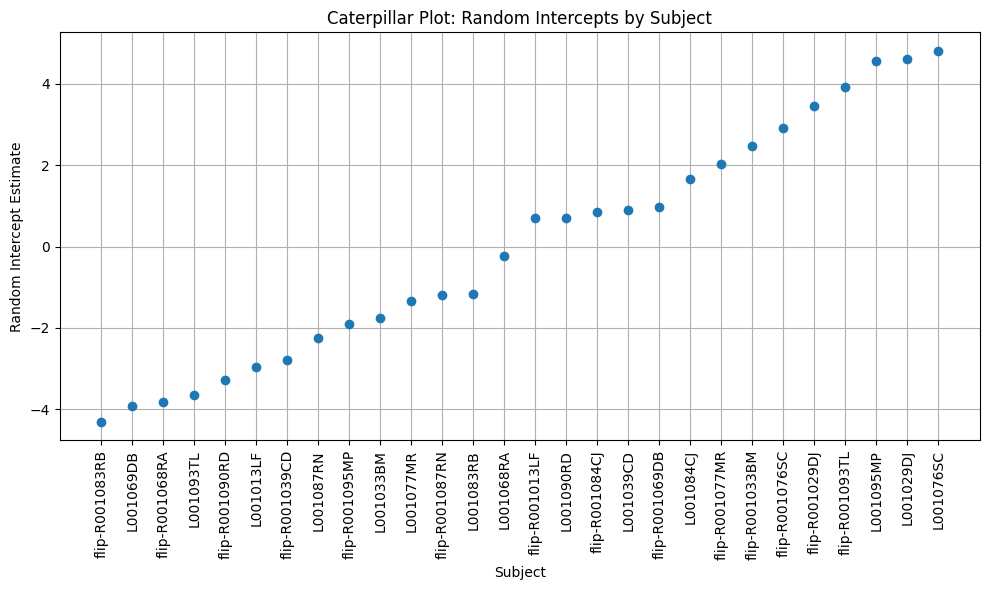

In [102]:
#################################  Caterpillar plot: detect outlier groups  ################################

re_df = pd.DataFrame(result.random_effects).T
re_df.columns = ['Random_Intercept'] if re_df.shape[1] == 1 else ['Random_Intercept', 'Random_Slope']
re_df = re_df.sort_values(by='Random_Intercept')  # or by 'Random_Slope'

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=range(len(re_df)),
    y=re_df['Random_Intercept'],
    fmt='o'
)
plt.xticks(range(len(re_df)), re_df.index, rotation=90)
plt.title("Caterpillar Plot: Random Intercepts by Subject")
plt.ylabel("Random Intercept Estimate")
plt.xlabel("Subject")
plt.grid(True)
plt.tight_layout()
plt.show()


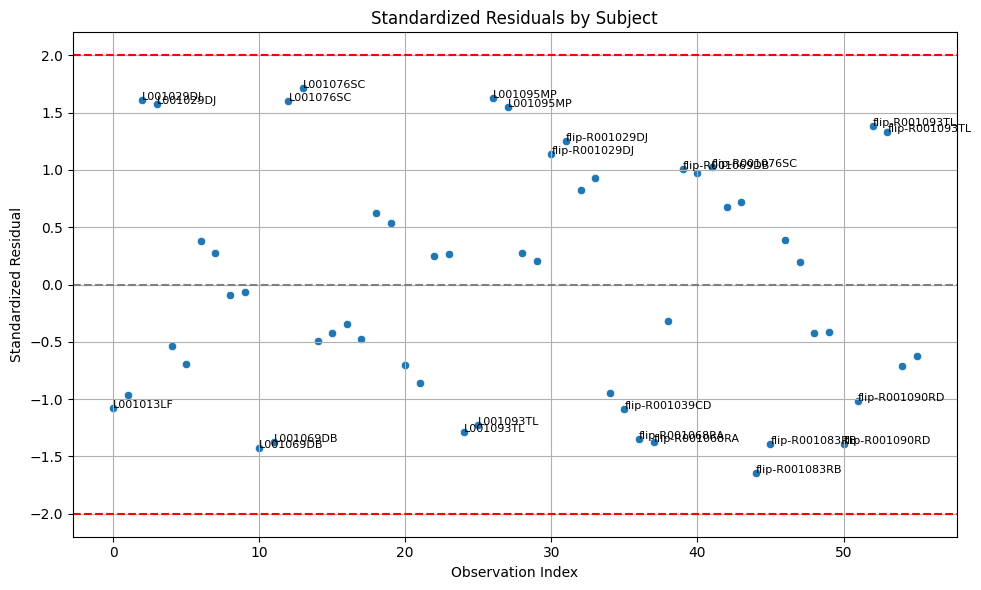

           subject  resid_studentized  abs_resid
13       L001076SC           1.715388   1.715388
44  flip-R001083RB          -1.642044   1.642044
26       L001095MP           1.629316   1.629316
2        L001029DJ           1.606526   1.606526
12       L001076SC           1.601463   1.601463
3        L001029DJ           1.575461   1.575461
27       L001095MP           1.552102   1.552102
10       L001069DB          -1.429251   1.429251
45  flip-R001083RB          -1.392256   1.392256
50  flip-R001090RD          -1.391590   1.391590


In [103]:
########################  outlier diagnosis, Standardized (or Studentized) Residuals Plot  #########################

df = combined_CAG_only_SCA_centered
# Example OLS model
model = smf.ols("UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + side", data=df).fit()

# Get standardized (internally studentized) residuals
influence = model.get_influence()
resid_studentized = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag

# Add to the dataframe
df["resid_studentized"] = resid_studentized
df["leverage"] = leverage

# Optionally add subject labels (ensure column exists)
subject_col = "ori_subjName"  # adapt as needed
df["subject"] = df[subject_col]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(len(df)), y="resid_studentized", data=df)

# Label points with high residuals
for i, row in df.iterrows():
    if abs(row["resid_studentized"]) > 1:  # label if large residual
        plt.text(i, row["resid_studentized"], str(row["subject"]), fontsize=8)

plt.axhline(0, linestyle="--", color="gray")
plt.axhline(2, linestyle="--", color="red")
plt.axhline(-2, linestyle="--", color="red")
plt.title("Standardized Residuals by Subject")
plt.xlabel("Observation Index")
plt.ylabel("Standardized Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# List top residuals
top_residuals = df.loc[:, ["subject", "resid_studentized"]].copy()
top_residuals["abs_resid"] = top_residuals["resid_studentized"].abs()
top_sorted = top_residuals.sort_values(by="abs_resid", ascending=False)
print(top_sorted.head(10))  # Top 10 subjects by residual size


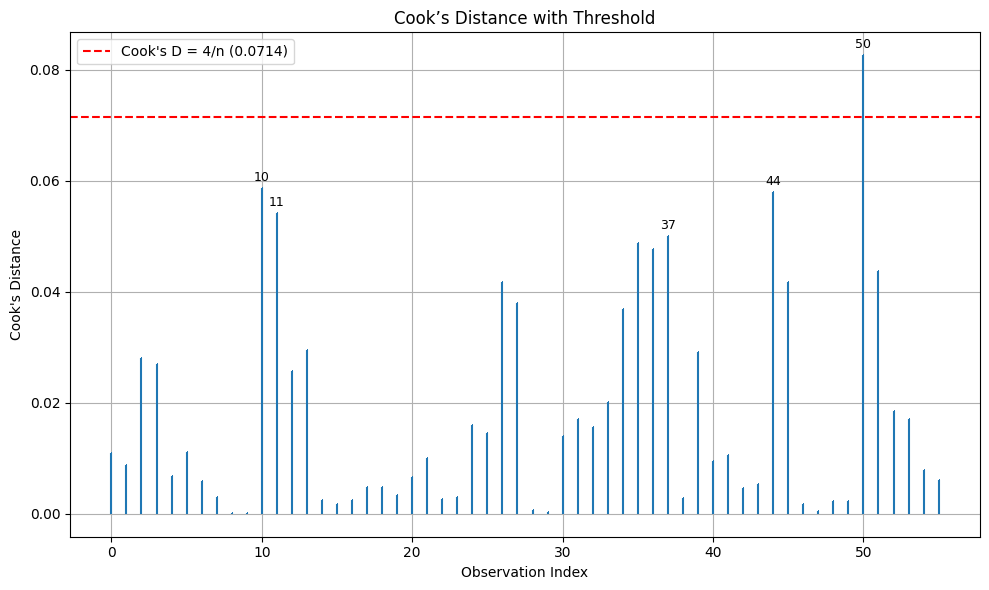


Top influential observations (by Cook's distance):
 obs_index   ori_subjName  cooks_d
        50 flip-R001090RD 0.082610
        10      L001069DB 0.058740
        44 flip-R001083RB 0.057970
        11      L001069DB 0.054259
        37 flip-R001068RA 0.050029


In [104]:
########################  outlier diagnosis, Cook's distance Plot  #########################

# 1. Compute Cook's distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# 2. Create DataFrame with observation index and subject info
df_cooks = pd.DataFrame({
    "obs_index": range(len(cooks_d)),
    "ori_subjName": df["ori_subjName"].values,  # assuming df has this column
    "cooks_d": cooks_d
})

# 3. Sort to get top N influential points
top_n = 5
top_cooks = df_cooks.sort_values("cooks_d", ascending=False).head(top_n)

# 4. Plot Cook’s Distance with threshold
plt.figure(figsize=(10, 6))
plt.stem(df_cooks["obs_index"], df_cooks["cooks_d"], markerfmt=",", basefmt=" ")

# Add Cook's D threshold line
n = len(df)  # number of observations
threshold = 4 / n
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Cook\'s D = 4/n ({threshold:.4f})')

# Annotate the top influential observations
for _, row in top_cooks.iterrows():
    plt.annotate(row["obs_index"],
                 (row["obs_index"], row["cooks_d"]),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

plt.title("Cook’s Distance with Threshold")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Print mapping of observation index to subject name
print("\nTop influential observations (by Cook's distance):")
print(top_cooks[["obs_index", "ori_subjName", "cooks_d"]].to_string(index=False))


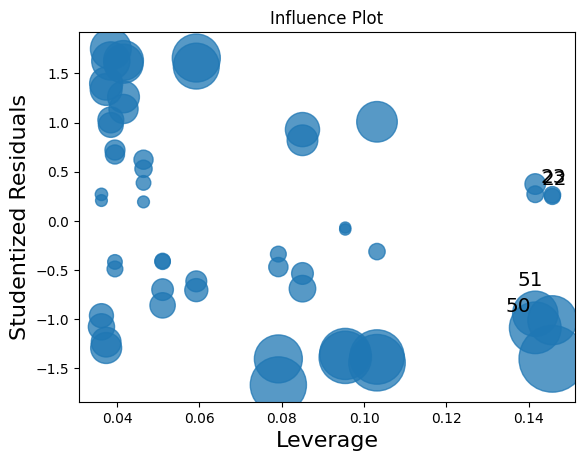

In [105]:
########################  outlier diagnosis, Influence Plot  #########################

sm.graphics.influence_plot(model, criterion="cooks")
plt.title("Influence Plot")
plt.show()


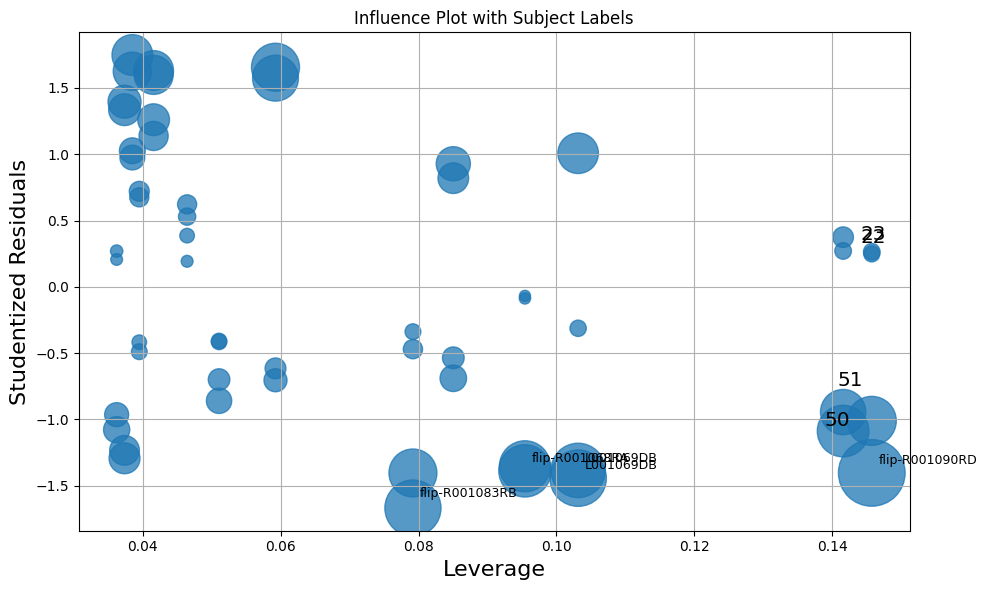


Top Influential Observations:
      ori_subjName   cooks_d  hat_diag  standard_resid
50  flip-R001090RD  0.082610  0.145763       -1.391590
10       L001069DB  0.058740  0.103156       -1.429251
44  flip-R001083RB  0.057970  0.079189       -1.642044
11       L001069DB  0.054259  0.103156       -1.373656
37  flip-R001068RA  0.050029  0.095441       -1.377180


In [106]:
########################  outlier diagnosis, Influence Plot, with subject name list  #########################

# Assuming you already have the model

# Get influence summary
influence = model.get_influence()
summary_frame = influence.summary_frame()

# Combine with your subject names
summary_frame["ori_subjName"] = df["ori_subjName"].values  # Ensure alignment

# Determine which points to label (e.g., top 5 by Cook's D)
top_cooks = summary_frame.nlargest(5, "cooks_d")

# Plot the influence plot
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
#sm.graphics.influence_plot(model, ax=ax, criterion="cooks", size=2)

# Annotate top influential points
for i in top_cooks.index:
    ax.annotate(df["ori_subjName"].iloc[i], 
                xy=(summary_frame.loc[i, 'hat_diag'], summary_frame.loc[i, 'standard_resid']),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

plt.title("Influence Plot with Subject Labels")
plt.grid(True)
plt.tight_layout()
plt.show()

# Display a table of the most influential subjects
print("\nTop Influential Observations:")
print(top_cooks[["ori_subjName", "cooks_d", "hat_diag", "standard_resid"]])


In [107]:
##############################  Plots studying the relationship between shape and CAG  ############################### 

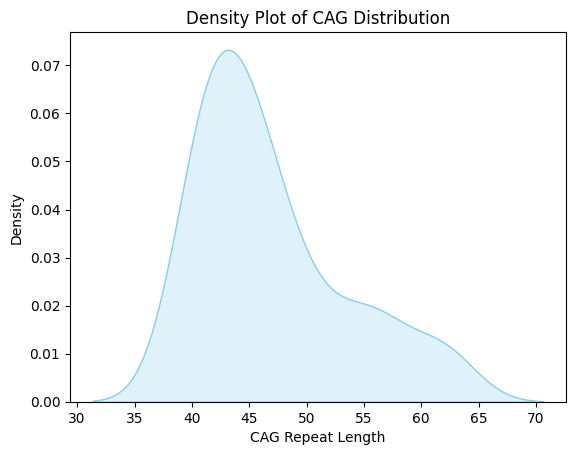

In [108]:
####################  Density plot of the CAG distribution  #####################

sns.kdeplot(data=df, x='CAG', fill=True, color='skyblue')
plt.xlabel('CAG Repeat Length')
plt.ylabel('Density')
plt.title('Density Plot of CAG Distribution')
plt.show()


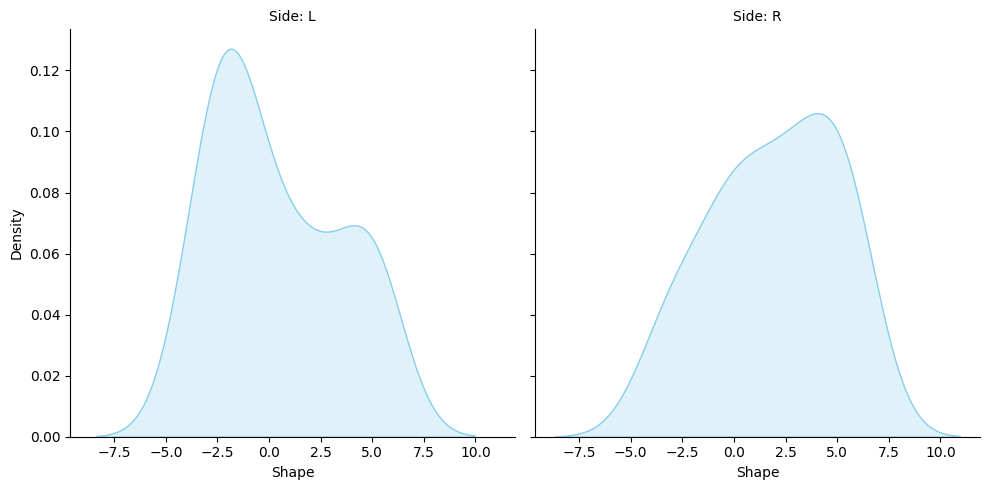

In [109]:
######################   Density plot of shape for the two hemispheres  #######################

g = sns.FacetGrid(df, col="side", height=5, aspect=1)
#g.map_dataframe(sns.kdeplot, x="iso1", fill=True, color='skyblue')
g.map_dataframe(sns.kdeplot, x="UMAP1_U2", fill=True, color='skyblue')
g.set_axis_labels("Shape", "Density")
g.set_titles("Side: {col_name}")
plt.tight_layout()
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_26240\4052868244.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CAG_bin', y='shape_resid', palette='Set2')


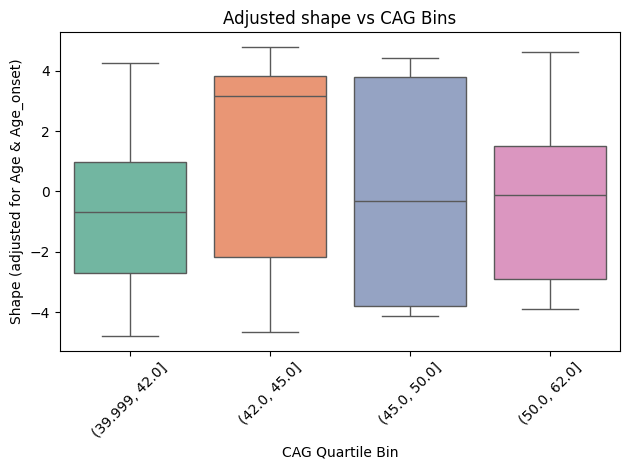

In [110]:
###################  Boxplots regressing out covariates  ###################

# Define predictors and add constant
X = df[['Age_onset']]
#X = df[['Age', 'Age_onset']]
X = sm.add_constant(X)

# Fit linear model: isomap ~ Age + Age_onset
#model = sm.OLS(df['iso1'], X).fit()
model = sm.OLS(df['UMAP1_U2'], X).fit()
df['shape_resid'] = model.resid  # residuals = isomap adjusted for Age and Age_onset

# Bin CAG into quartiles (or use custom bins)
df['CAG_bin'] = pd.qcut(df['CAG'], q=4)

# Plot residualized isomap vs binned CAG
sns.boxplot(data=df, x='CAG_bin', y='shape_resid', palette='Set2')
plt.xlabel('CAG Quartile Bin')
plt.ylabel('Shape (adjusted for Age & Age_onset)')
plt.title('Adjusted shape vs CAG Bins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


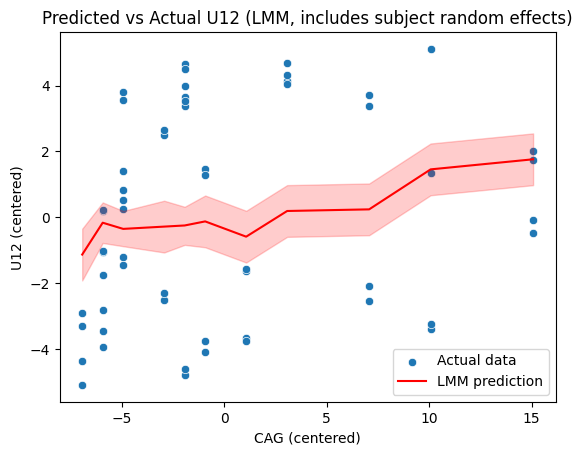

In [111]:
#############################  model fit plot, fixed plus random effect  #############################

# Predict values from the full mixed effects model (includes random effects)
df["predicted_U12"] = result.predict(df)

# Scatter actual data
sns.scatterplot(data=df, x="CAG_centered", y="UMAP1_U2_centered", label="Actual data")

# Add subject-level fitted line
sns.lineplot(data=df.sort_values("CAG_centered"), 
             x="CAG_centered", y="predicted_U12", color="red", label="LMM prediction")

plt.title("Predicted vs Actual U12 (LMM, includes subject random effects)")
plt.xlabel("CAG (centered)")
plt.ylabel("U12 (centered)")
plt.legend()
plt.show()


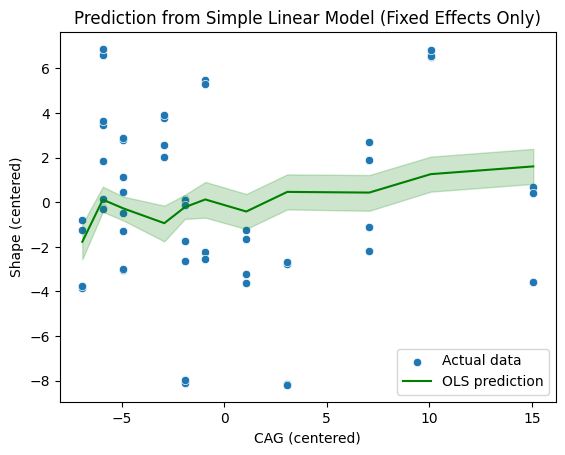

In [112]:
###########  model fit without random effects  #############

# Fit a simple OLS model (no random effects)
lm_result = smf.ols("UMAP1_U2_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)", data=df).fit()

# Predict values
df["ols_pred"] = lm_result.predict(df)

# Plot
sns.scatterplot(data=df, x="CAG_centered", y="iso1_centered", label="Actual data")
sns.lineplot(data=df.sort_values("CAG_centered"), 
             x="CAG_centered", y="ols_pred", color="green", label="OLS prediction")

plt.title("Prediction from Simple Linear Model (Fixed Effects Only)")
plt.xlabel("CAG (centered)")
plt.ylabel("Shape (centered)")
plt.legend()
plt.show()


In [113]:
##################  Compare models with and without interaction term  ###################
################## Split the data into left and right hemisphere subsets and run separate models  ###################
##################  Note that this count as multiple testing, correction needed  ####################
df = combined_CAG_only_SCA_centered

def test_LMM(df,measure):
    x_var = 'CAG_centered'          # DEFAULT
    covariates = 'Age_onset_centered + C(side)'  # DEFAULT 

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
    )
    result = model_lmm.fit()
    print(result.summary())

def test_LMM_interaction_side(df,measure):
    x_var = 'CAG_centered*C(side)'           # Estimating different slopes and intercepts for left and right hemispheres
                                             # Testing whether, for example, CAG influences left and right hemispheres differently 
    covariates = 'Age_onset_centered'        # If moving side to x_var as interaction term

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
    )
    result = model_lmm.fit()
    print(result.summary())

####################################################################################################
df = combined_CAG_only_SCA_centered

df_L = df[df['side'] == 'L']
df_R = df[df['side'] == 'R']

curMeasure = 'UMAP1_U2_centered'

test_LMM(df,curMeasure)
print('__________________Interaction side____________________')
print()
test_LMM_interaction_side(df,curMeasure)
print('__________________Left hemisphere____________________')
print()
test_LMM(df_L,curMeasure)
print('__________________Right hemisphere___________________')
print()
test_LMM(df_R,curMeasure)

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: UMAP1_U2_centered
No. Observations: 56      Method:             REML             
No. Groups:       28      Scale:              0.3189           
Min. group size:  2       Log-Likelihood:     -103.9542        
Max. group size:  2       Converged:          Yes              
Mean group size:  2.0                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -0.785    0.829 -0.947 0.344 -2.411  0.840
C(side)[T.R]          1.571    1.173  1.339 0.180 -0.728  3.870
CAG_centered          0.257    0.255  1.005 0.315 -0.244  0.757
Age_onset_centered    0.089    0.136  0.652 0.514 -0.178  0.356
Group Var             9.472    6.710                           

__________________Interaction side__________________

In [114]:
#### Is the hemispheric difference in shape different depending on SCA type? ####
# Whether there's a general left vs. right difference in shape (C(side)).
# Whether different SCA types show different average shape (C(SCA)).
# Whether hemisphere differences (left-right) are different for different SCA types (C(side):C(SCA) — the interaction).

df = combined_centered  ###  testing at least two different SCA types

model = smf.mixedlm(
#    formula="iso1_centered ~ C(side) * C(SCA) + Age_centered + Sex",   # centered or not, same p-val
#    formula="iso1 ~ C(side) * C(SCA) + Age + Sex",   
    formula="UMAP1_U2_centered ~ C(side) * C(SCA) + Age_centered + Sex",      
    data=df,
    groups=df['ori_subjName']
)
result = model.fit()
print(result.summary())


               Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  UMAP1_U2_centered
No. Observations:   160      Method:              REML             
No. Groups:         80       Scale:               0.7416           
Min. group size:    2        Log-Likelihood:      -325.6872        
Max. group size:    2        Converged:           Yes              
Mean group size:    2.0                                            
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -1.608    1.156 -1.391 0.164 -3.874  0.658
C(side)[T.R]              1.017    0.824  1.234 0.217 -0.599  2.632
C(SCA)[T.1]               0.501    0.960  0.522 0.602 -1.380  2.382
C(side)[T.R]:C(SCA)[T.1]  0.509    1.346  0.378 0.705 -2.129  3.147
Age_centered              0.040    0.023  1.741 0.082 -0.005  0

                Age  Age_onset
Age        1.000000   0.915209
Age_onset  0.915209   1.000000


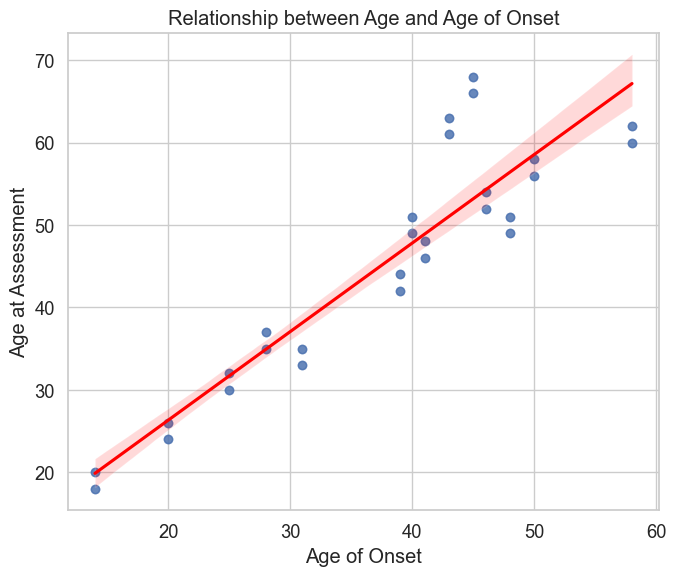

In [115]:
#####################  Study the relationship between age and age_onset  ######################
print(df[['Age', 'Age_onset']].corr())

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.regplot(data=df, x='Age_onset', y='Age', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.xlabel('Age of Onset')
plt.ylabel('Age at Assessment')
plt.title('Relationship between Age and Age of Onset')
plt.tight_layout()
plt.show()


                CAG  Age_onset
CAG        1.000000  -0.933329
Age_onset -0.933329   1.000000


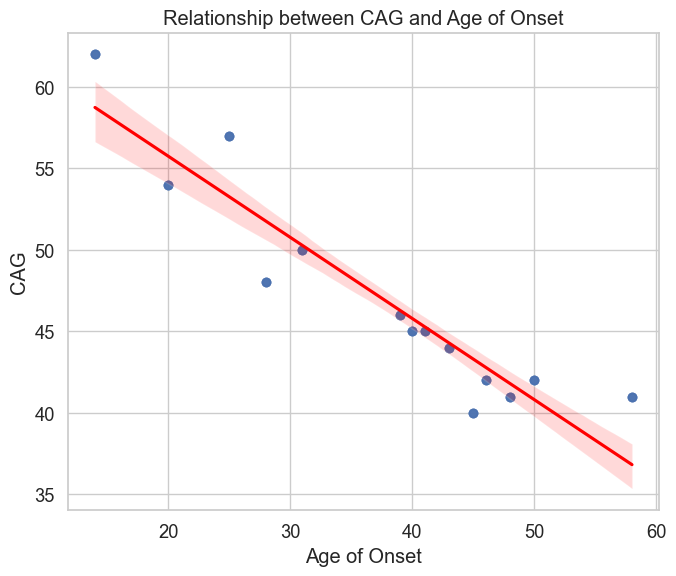

In [116]:
##################  Study the relationship between CAG and age_onset
print(df[['CAG', 'Age_onset']].corr())

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.regplot(data=df, x='Age_onset', y='CAG', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.xlabel('Age of Onset')
plt.ylabel('CAG')
plt.title('Relationship between CAG and Age of Onset')
plt.tight_layout()
plt.show()
